## 4. Building ChatBot application integrating it with multiple tools

In [11]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from dotenv import load_dotenv
import os
load_dotenv()

True

In [16]:
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")  

In [3]:
api_wrapper=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv_tool=ArxivQueryRun(api_wrapper=api_wrapper)

In [4]:
arxiv_tool.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wikipedia_tool=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wikipedia_tool.invoke("Artificial General Intelligence")

'Page: Artificial general intelligence\nSummary: Artificial general intelligence (AGI) is a type of artificial intelligence that matches or surpasses human capabilities across virtually all cognitive tasks.\nBeyond AGI, artificial superintelligence (ASI) would outperform the best human abilities across every domain by a wide margin. Unlike artificial narrow intelligence (ANI), whose competence is confined to well‑defined tasks, an AGI system can generalise knowledge, transfer skills between domains'

In [9]:
from langchain_tavily import TavilySearch

In [13]:
tavily_tool=TavilySearch(
    max_results=5)

tavily_tool.invoke("What is the latest research on Artificial General Intelligence?")



{'query': 'What is the latest research on Artificial General Intelligence?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Artificial_general_intelligence',
   'title': 'Artificial general intelligence',
   'content': 'A 2020 survey identified 72 active AGI research and development projects across 37 countries. AGI is a common topic in science fiction and futures studies.',
   'score': 0.9987356,
   'raw_content': None},
  {'url': 'https://www.sciencedirect.com/science/article/abs/pii/S1367578825000367',
   'title': 'Path to Artificial General Intelligence: Past, present, and future',
   'content': 'by R Sarikaya · 2025 · Cited by 5 — We then examine how advances in computational infrastructure, algorithms, and large-scale modeling are converging to drive the generative AI revolution and',
   'score': 0.9966234,
   'raw_content': None},
  {'url': 'https://www.iberdrola.com/about-us/our-innovation-model/general-ai',
   

In [14]:
tools=[arxiv_tool,wikipedia_tool,tavily_tool]

### Creating Orchestration using Langgraph

In [15]:
from langchain.agents import create_agent

In [22]:
agent=create_agent(model="groq:llama-3.1-8b-instant",tools=tools)

In [28]:
from langchain_core.messages import HumanMessage

results=agent.invoke({"messages": [HumanMessage(content="What is the latest research on Artificial General Intelligence?")]})

In [31]:
from pprint import pprint

for m in results["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the latest research on Artificial General Intelligence?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (s1ayw3td9)
 Call ID: s1ayw3td9
  Args:
    query: latest research Artificial General Intelligence
    time_range: month
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest research Artificial General Intelligence", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://pmc.ncbi.nlm.nih.gov/articles/PMC12932417/", "title": "The future of fundamental science led by generative closed-loop ...", "content": "Looking ahead, the advent of artificial general intelligence (AGI) could further transform hypothesis generation by decoupling it from human cognitive priors", "score": 0.38228035, "raw_content": null}, {"url": "https

In [38]:
from pydantic import BaseModel,Field
from langgraph.graph.message import add_messages,Annotated,AnyMessage


In [34]:
class State(BaseModel):
    messages:Annotated[list[AnyMessage],add_messages]=Field(...,description="The list of messages in the conversation")

In [35]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

In [53]:
# Node definition
def tool_with_llm(state:State):
    response=agent.invoke({"messages":state.messages})
    return {"messages":response["messages"]}

In [54]:
#Building the graph
builder=StateGraph(State)
builder.add_node("tool_with_llm",tool_with_llm)
builder.add_node("tools",ToolNode(tools=tools))
# Add edges
builder.add_edge(START,"tool_with_llm")
builder.add_conditional_edges("tool_with_llm",tools_condition)
builder.add_edge("tools",END)

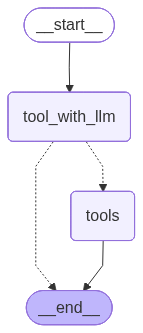

In [55]:
graph=builder.compile()
graph

In [58]:
results=graph.invoke({"messages":[HumanMessage(content="What is the news in kolkata?")]})

In [59]:
for m in results["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the news in kolkata?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f9y6xkwjh)
 Call ID: f9y6xkwjh
  Args:
    query: kolkata news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "kolkata news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.islandernews.com/news/national/kaiwei-tang-said-self-control-is-not-enough-to-master-attention/image_354c0fe6-3576-52f3-b0ef-27ecbdb80ae6.html", "title": "Kaiwei Tang said self-control is not enough to master attention - IslanderNews.com", "score": 0.0074317735, "published_date": "Thu, 05 Mar 2026 11:03:36 GMT", "content": "You have permission to edit this image. + #### Log In Using Your Account. **Don't have an account?** Sign Up Today. ##### Today. Winds